<a href="https://colab.research.google.com/github/ishuu9837/Multimodal-Document-Understanding-using-Qwen2.5-VL/blob/main/Multimodal_Document_Understanding_using_Qwen2_5_VL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip -q install transformers accelerate bitsandbytes
!pip -q install qwen-vl-utils
!pip -q install easyocr
!pip -q install gradio
!pip -q install pillow
!pip -q install pdf2image
!pip -q install sentencepiece
!pip -q install einops
!pip -q install torchvision
!pip -q install huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 28.4 MB/s eta 0:00:00


In [2]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))

In [3]:
import torch
from PIL import Image
import easyocr

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
)

from qwen_vl_utils import process_vision_info

In [4]:
MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_NAME)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model Loaded Successfully!")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model Loaded Successfully!


Saving word-invoice-template.png to word-invoice-template.png


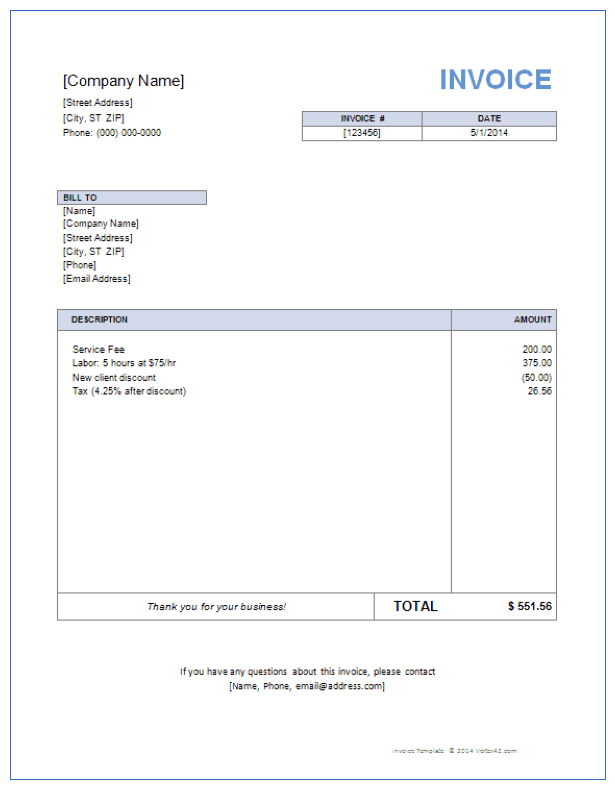

In [5]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8,10))
plt.imshow(image)
plt.axis("off")
plt.show()

In [6]:
import easyocr

reader = easyocr.Reader(['en'])

ocr_results = reader.readtext(image_path)

print("OCR Output:\n")

for result in ocr_results:
    print(result[1])


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR Output:

[Company Name]
INVOICE
[Sitee; A-zres]
[Ctty, ST Zipd
IMVOICE
CETE
Frora
ex
[245]
71z074
IName]
Comcary Nama]
[8itee; A-ztes3
[Ctty, ST Zipd
Frora]
JEma
Aiss 
cescriptON
L4ouht
Senvke Fes
Zoo.0d
Lacor
cons
3; 375tr
375.10
Nem c ler: Cigcolrt
(50.82}
25%: after JiscoLnt}
15
Thank you forycur busines:'
TOTAL
551,56
Ifyou rav
ar qmeon
about thb irvoize
Ozaee
Cocta CC
[Nanta
@3w
Te_= D
204 ss4
Ron?


In [7]:
ocr_text = "\n".join([res[1] for res in ocr_results])

print(ocr_text)

[Company Name]
INVOICE
[Sitee; A-zres]
[Ctty, ST Zipd
IMVOICE
CETE
Frora
ex
[245]
71z074
IName]
Comcary Nama]
[8itee; A-ztes3
[Ctty, ST Zipd
Frora]
JEma
Aiss 
cescriptON
L4ouht
Senvke Fes
Zoo.0d
Lacor
cons
3; 375tr
375.10
Nem c ler: Cigcolrt
(50.82}
25%: after JiscoLnt}
15
Thank you forycur busines:'
TOTAL
551,56
Ifyou rav
ar qmeon
about thb irvoize
Ozaee
Cocta CC
[Nanta
@3w
Te_= D
204 ss4
Ron?


In [8]:
question = "Summarize this document."

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {
                "type": "text",
                "text": question,
            },
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=256
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

response = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)

print(response[0])

This document is an invoice template for a company named [Company Name]. The invoice includes the following details:

- Invoice number: 123456
- Date: 5/1/2014
- Bill to: [Name], [Company Name], [Street Address], [City, ST ZIP], [Phone], [Email Address]
- Description of services:
  - Service Fee: $200.00
  - Labor (5 hours at $75/hr): $375.00
  - New client discount: -$50.00
  - Tax (4.25% after discount): $26.56
- Total amount: $551.56

The invoice also includes a thank you note and contact information for any questions about the invoice.


In [9]:
def ask_document(question, image):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": question,
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=256
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    answer = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return answer

In [10]:
question = "Summarize this document."

print(ask_document(question, image))

This document is an invoice template for a company named [Company Name]. The invoice includes the following details:

- Invoice number: 123456
- Date: 5/1/2014
- Bill to: [Name], [Company Name], [Street Address], [City, ST ZIP], [Phone], [Email Address]
- Description of services:
  - Service Fee: $200.00
  - Labor (5 hours at $75/hr): $375.00
  - New client discount: -$50.00
  - Tax (4.25% after discount): $26.56
- Total amount: $551.56

The invoice also includes a thank you note and contact information for any questions about the invoice.


In [11]:
print(ask_document("Who issued this document?", image))
print(ask_document("What is the invoice number?", image))
print(ask_document("What is the total amount?", image))
print(ask_document("List all important fields.", image))

The document is an invoice from [Company Name].
The invoice number is 123456.
The total amount on the invoice is $551.56.
Certainly! Here is a list of the important fields typically found on an invoice:

1. **Company Name**
2. **Street Address**
3. **City, ST ZIP**
4. **Phone Number**
5. **Invoice Number**
6. **Date**
7. **Bill To:**
   - **Name**
   - **Company Name**
   - **Street Address**
   - **City, ST ZIP**
   - **Phone Number**
   - **Email Address**
8. **Description**
9. **Amount**
10. **Total Amount**

These fields help in organizing and providing clear information about the transaction, making it easier for both the sender and the recipient to understand the details of the invoice.


In [12]:
import gradio as gr
from PIL import Image

def document_chat(img, question):
    if img is None:
        return "Please upload an image."

    return ask_document(question, img)

demo = gr.Interface(
    fn=document_chat,
    inputs=[
        gr.Image(type="pil", label="Upload Document"),
        gr.Textbox(
            label="Ask a Question",
            placeholder="Example: Summarize this document"
        )
    ],
    outputs=gr.Textbox(label="Answer"),
    title="Multimodal Document Understanding using Qwen2.5-VL",
    description="Upload a document and ask questions."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ebee076281d6124ad6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
!apt-get install poppler-utils -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12
Err:1 http://security.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12
  404  Not Found [IP: 172.66.152.176 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/p/poppler/poppler-utils_22.02.0-2ubuntu0.12_amd64.deb  404  Not Found [IP: 172.66.152.176 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?
